Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

print('Libraries imported!')

Setting up path

In [2]:
base_path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\data_image\OriginalDataset'

classes = ['MildDemented', 'ModerateDemented', 
           'NonDemented', 'VeryMildDemented']

print(f' Base Path Set!')
print(f'️ Classes: {classes}')

# Check karo sab folders hain
print('\n Checking folders:')
for cls in classes:
    path = os.path.join(base_path, cls)
    if os.path.exists(path):
        print(f'   {cls} — Found')
    else:
        print(f'   {cls} — NOT Found!')

 Base Path Set!
️ Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

 Checking folders:
   MildDemented — Found
   ModerateDemented — Found
   NonDemented — Found
   VeryMildDemented — Found


In [3]:
image_counts = {}
total = 0

print('Image Count Per Class:')
print('-' * 40)

for cls in classes:
    path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(path) 
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    image_counts[cls] = len(images)
    total += len(images)
    print(f'   {cls}: {len(images)} images')

print('-' * 40)
print(f'   TOTAL: {total} images')

Image Count Per Class:
----------------------------------------
   MildDemented: 896 images
   ModerateDemented: 64 images
   NonDemented: 3200 images
   VeryMildDemented: 2240 images
----------------------------------------
   TOTAL: 6400 images


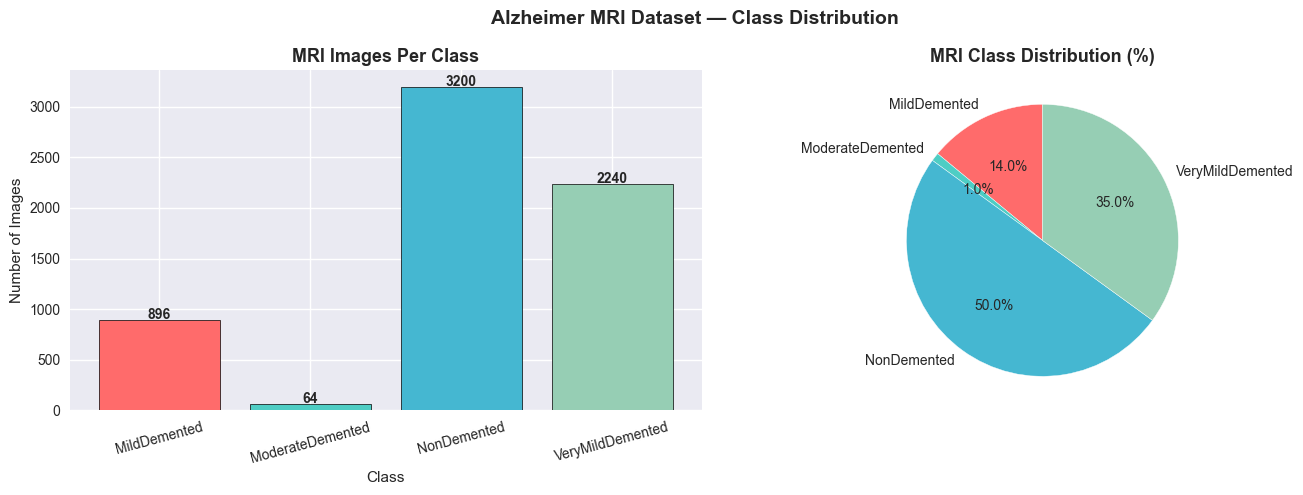

Plot saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = np.array(axes).flatten()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Bar chart
bars = axes[0].bar(image_counts.keys(), 
                   image_counts.values(), 
                   color=colors, 
                   edgecolor='black', 
                   linewidth=0.5)
axes[0].set_title('MRI Images Per Class', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, image_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2., 
                 bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(image_counts.values(), 
            labels=image_counts.keys(),
            autopct='%1.1f%%', 
            colors=colors, 
            startangle=90)
axes[1].set_title('MRI Class Distribution (%)', 
                  fontsize=13, fontweight='bold')

plt.suptitle('Alzheimer MRI Dataset — Class Distribution', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('image_class_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

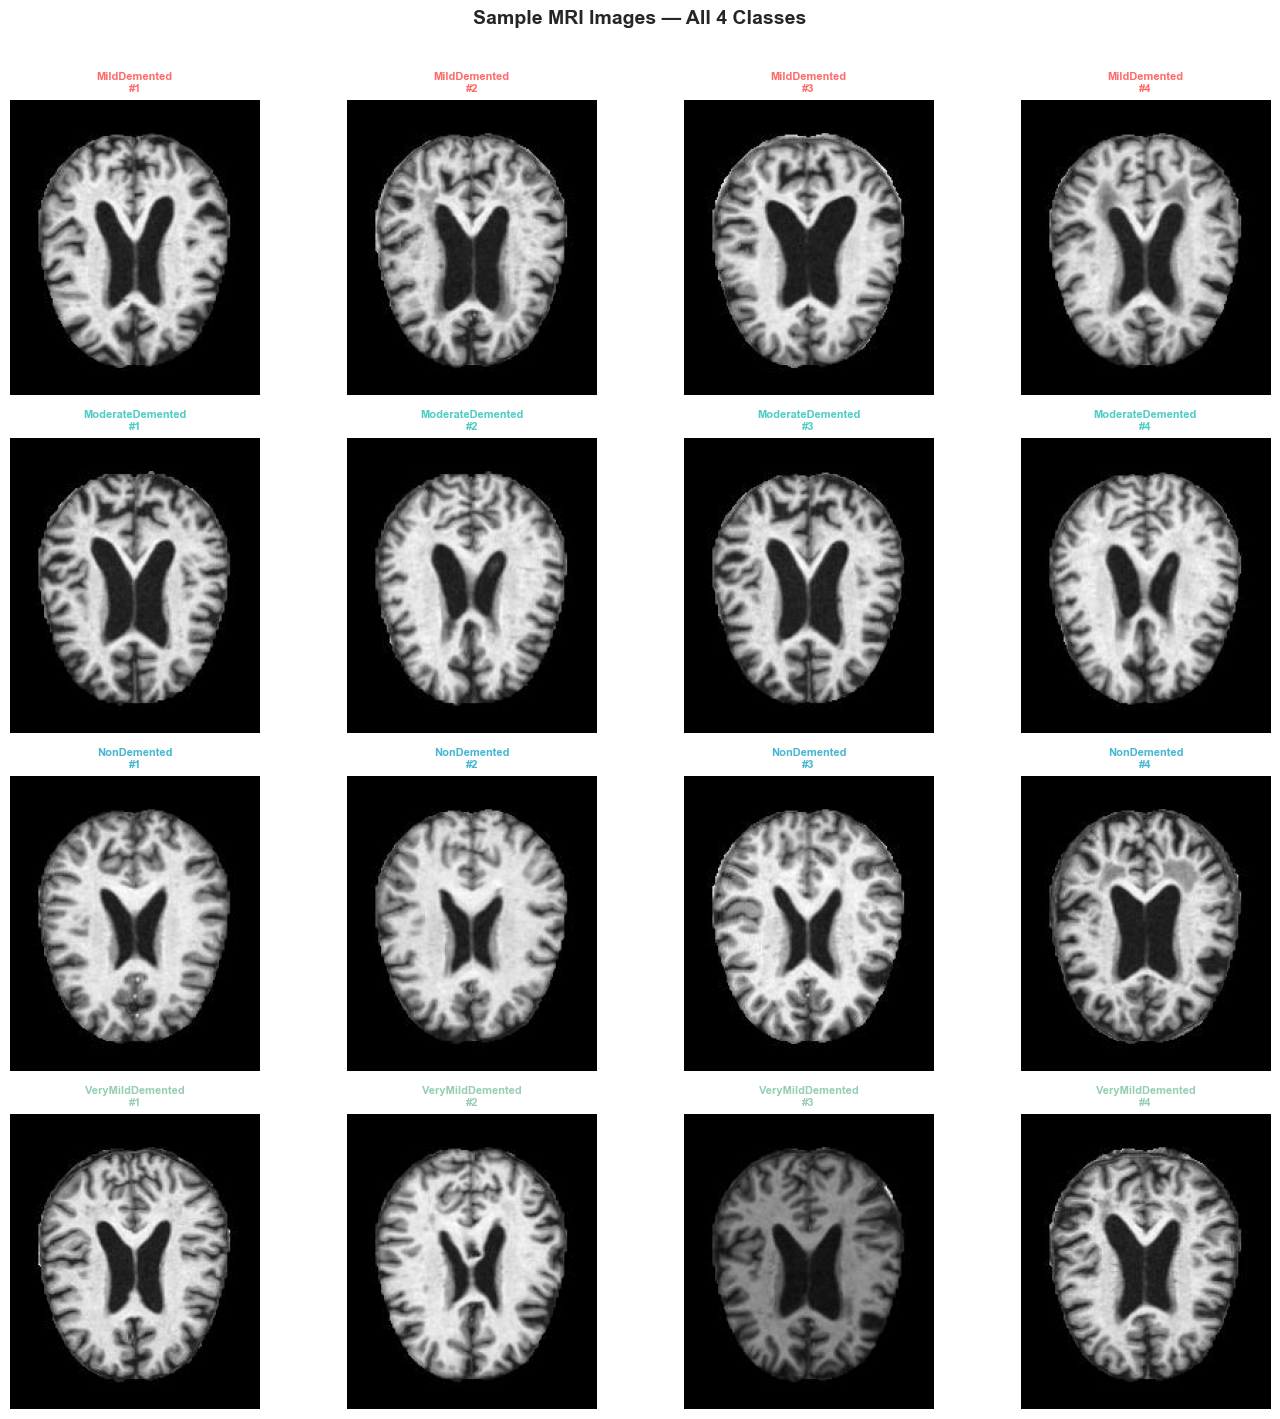

Sample images saved!


In [5]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
colors_title = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for row, (cls, color) in enumerate(zip(classes, colors_title)):
    cls_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(cls_path) 
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    
    for col in range(4):
        if col < len(images):
            img_path = os.path.join(cls_path, images[col])
            img = Image.open(img_path).convert('RGB')
            axes[row][col].imshow(img, cmap='gray')
            axes[row][col].axis('off')
            axes[row][col].set_title(f'{cls}\n#{col+1}', 
                                     fontsize=8, color=color,
                                     fontweight='bold')

plt.suptitle('Sample MRI Images — All 4 Classes', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_mri_images.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Sample images saved!')

In [6]:
print('Image Sizes Check:')
print('-' * 40)

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(cls_path) 
              if f.lower().endswith(('.jpg','.jpeg','.png'))][:3]
    
    print(f'\n {cls}:')
    for img_name in images:
        img = Image.open(os.path.join(cls_path, img_name))
        print(f'   {img_name}: {img.size} — Mode: {img.mode}')

print('\n Images will be resized to 224x224 for model training')

Image Sizes Check:
----------------------------------------

 MildDemented:
   26 (19).jpg: (176, 208) — Mode: L
   26 (20).jpg: (176, 208) — Mode: L
   26 (21).jpg: (176, 208) — Mode: L

 ModerateDemented:
   27 (2).jpg: (176, 208) — Mode: L
   27.jpg: (176, 208) — Mode: L
   28 (2).jpg: (176, 208) — Mode: L

 NonDemented:
   26 (100).jpg: (176, 208) — Mode: L
   26 (62).jpg: (176, 208) — Mode: L
   26 (63).jpg: (176, 208) — Mode: L

 VeryMildDemented:
   26 (44).jpg: (176, 208) — Mode: L
   26 (45).jpg: (176, 208) — Mode: L
   26 (46).jpg: (176, 208) — Mode: L

 Images will be resized to 224x224 for model training


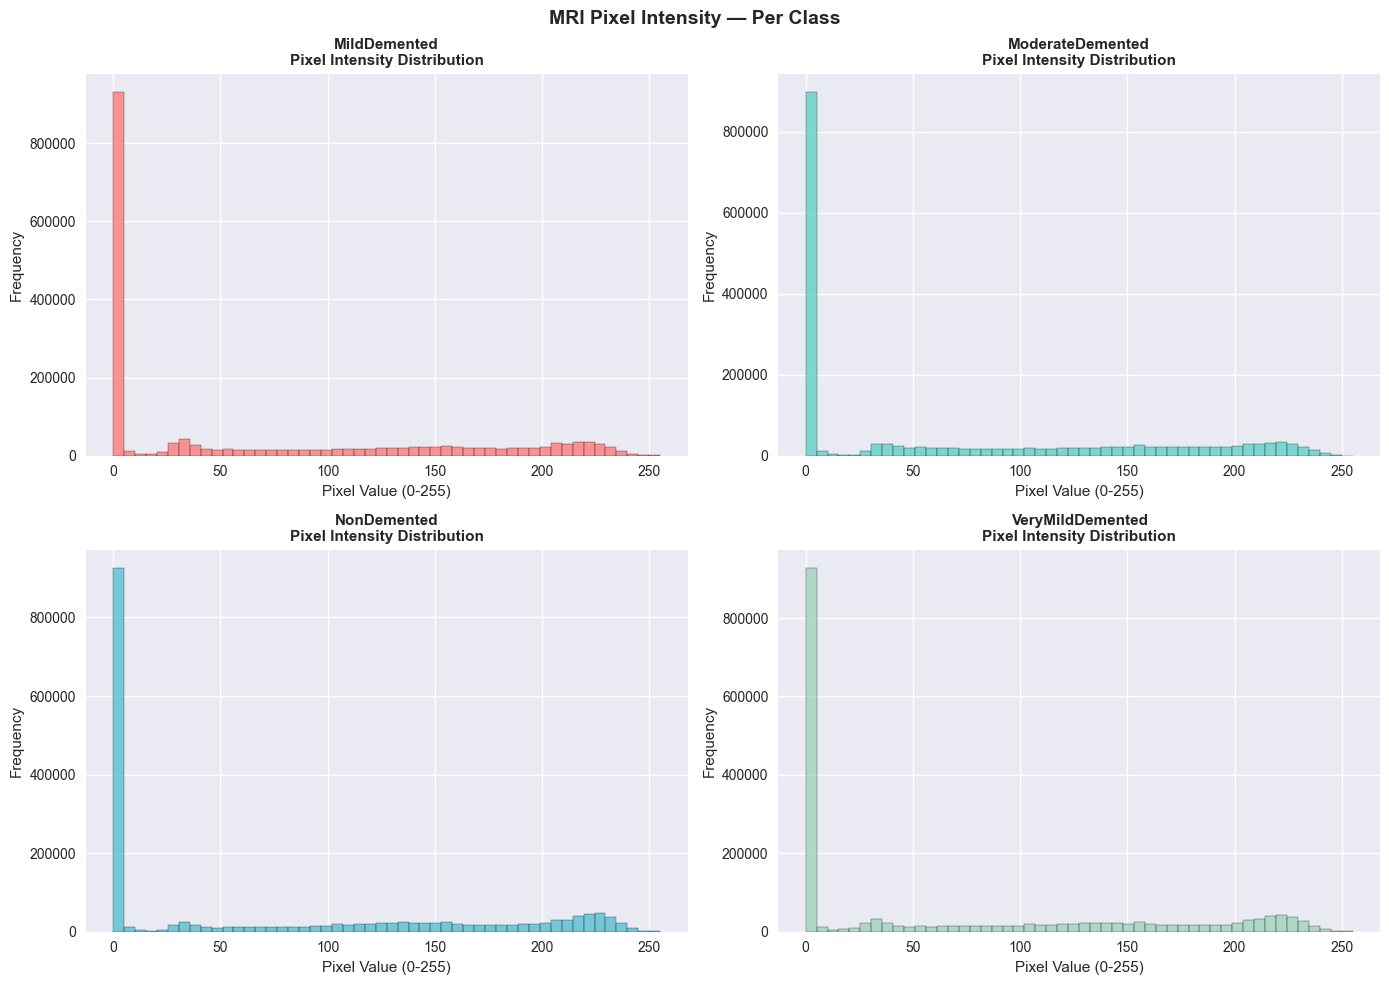

Plot saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for idx, (cls, color) in enumerate(zip(classes, colors)):
    cls_path = os.path.join(base_path, cls)
    all_images = [f for f in os.listdir(cls_path) 
                  if f.lower().endswith(('.jpg','.jpeg','.png'))][:50]
    
    pixel_values = []
    for img_name in all_images:
        img = Image.open(os.path.join(cls_path, 
                         img_name)).convert('L')
        img_array = np.array(img).flatten()
        pixel_values.extend(img_array.tolist())
    
    axes[idx].hist(pixel_values, bins=50, color=color, 
                   alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[idx].set_title(f'{cls}\nPixel Intensity Distribution', 
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Pixel Value (0-255)')
    axes[idx].set_ylabel('Frequency')

plt.suptitle('MRI Pixel Intensity — Per Class', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

In [9]:
print('=' * 50)
print('IMAGE DATASET — EDA SUMMARY')
print('=' * 50)
print(f' Dataset Used     : OriginalDataset')
print(f' Total Classes    : {len(classes)}')
print(f' Total Images     : {total}')
print()
print('Per Class Breakdown:')
for cls, cnt in image_counts.items():
    print(f'   → {cls}: {cnt} ({cnt/total*100:.1f}%)')
print()
print('Next Steps:')
print('   → Images resize : 224x224')
print('   → Normalize: 0-1 range')
print('   → Split: 70% Train, 15% Val, 15% Test')
print('=' * 50)
print('Image EDA Complete!')

IMAGE DATASET — EDA SUMMARY
 Dataset Used     : OriginalDataset
 Total Classes    : 4
 Total Images     : 6400

Per Class Breakdown:
   → MildDemented: 896 (14.0%)
   → ModerateDemented: 64 (1.0%)
   → NonDemented: 3200 (50.0%)
   → VeryMildDemented: 2240 (35.0%)

Next Steps:
   → Images resize : 224x224
   → Normalize: 0-1 range
   → Split: 70% Train, 15% Val, 15% Test
Image EDA Complete!
